In [19]:
# Utils
# ==============================================================================
import warnings

# Plot
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Data
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import make_friedman1, make_regression, make_classification

# Model
# ==============================================================================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Metrics
# ==============================================================================
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    recall_score,
    precision_score)

# **Info**
---

**@By**: Steven Bernal

**@Nickname:** Kaiziferr

**@Git**: https://github.com/Kaiziferr

# **Data Context**
---

**Project Context**
The focus of this project is to demonstrate the process of post-pruning in decision trees.

**Data Source**
Synthetic Data

**Data Description**
A synthetic nonlinear dataset will be generated for the regression problem, along with a separate dataset for the classification problem.

# **Config**
---

The global settings for code execution were established. First, the visual style of the plots was configured using Seaborn with the darkgrid style. A random seed of 12354 was also defined to ensure reproducibility for processes involving random number generation. Finally, the environment was configured to suppress warning messages during execution, resulting in cleaner and more readable outputs.

In [20]:
sns.set(style="darkgrid")
random_seed = 12354
warnings.filterwarnings('ignore')

# **Liner Regressor**
---

The make_friedman1 function from scikit-learn was used to generate a synthetic dataset with a non-linear relationship between the predictor variables and the target variable. The dataset consists of 1000 observations and 8 predictor variables, with a noise level of 1.8. The previously defined random seed (12354)

In [21]:
X, y = make_friedman1(n_samples=2000, n_features=8, noise=1.8, random_state=random_seed)

**Data Split**

The dataset was split into training and test sets using `train_test_split`. 90% of the observations were allocated to the training set, while the remaining 10% were reserved for model evaluation. The previously defined random seed (`12354`) was used to ensure that the split was reproducible.


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.9, random_state = random_seed)

The training set is further split into two subsets: 85% is retained for training, while the remaining 15% is used for validation. The random_state parameter ensures that the split is reproducible.

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size = 0.85, random_state = random_seed)

**Model**


A decision tree regression model was initialized using DecisionTreeRegressor. The previously defined random seed (12354) was used to ensure reproducibility.

In [24]:
model_regresion = DecisionTreeRegressor(random_state=random_seed)

The tree’s cost-complexity pruning path was calculated using only the training set. This provided the different ccp_alpha values and the total impurity associated with each pruning level.

In [25]:
cost = model_regresion.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = cost.ccp_alphas, cost.impurities

This process evaluates each candidate `ccp_alpha` value obtained from the pruning path. For each value, a decision tree is trained, and several metrics are recorded to assess both its performance and complexity, including MAE, R², number of nodes, and maximum depth. In addition, 10-fold cross-validation is performed on the training set to obtain an additional estimate of the model's MAE.

The validation set (`X_val`, `y_val`) is used to evaluate the performance of each tree and select the `ccp_alpha` that provides the best results. The test set (`X_test`, `y_test`) is not involved in this process because it must remain isolated from model selection decisions. Using the test set to select `ccp_alpha` would introduce information from the data reserved for the final evaluation, compromising its role as an independent measure of the model's generalization performance.

In [26]:
# Initialize lists to store the number of nodes for each pruned tree
node_counts = []
# Initialize a list to store the maximum depth of each pruned tree
depth = []
# Initialize a list to store the MAE on the training set for each ccp_alpha
train_scores = []
# Initialize a list to store the MAE on the validation set for each ccp_alpha
val_scores = []
# Initialize a list to store each trained decision tree
models = []
# Initialize a list to store the mean cross-validation MAE for each ccp_alpha
cro_cv = []
# Initialize a list to store the R² score on the training set for each ccp_alpha
score_trainer = []
# Initialize a list to store the R² score on the test set for each ccp_alpha
score_val = []
# Initialize a list to store the R² score on the validation set for each ccp_alpha
for ccp_alpha in ccp_alphas:
  # Initialize a decision tree with the current ccp_alpha value
  model = DecisionTreeRegressor(random_state=random_seed, ccp_alpha=ccp_alpha)
  # Evaluate the model using 10-fold cross-validation on the training set
  # and convert the negative MAE returned by scikit-learn to the standard positive MAE
  cro_cv.append(-1*cross_val_score(model, X_train, y_train, cv=10, scoring='neg_mean_absolute_error').mean())
  # Fit the tree using the training data
  model.fit(X_train, y_train)
  # Store the R² score obtained on the training set
  score_trainer.append(model.score(X_train, y_train))
  # Store the R² score obtained on the test set
  score_val.append(model.score(X_val, y_val))
  # Store the number of nodes in the pruned tree
  node_counts.append(model.tree_.node_count)
  # Store the maximum depth of the pruned tree
  depth.append(model.tree_.max_depth)
  # Calculate and store the MAE on the training set
  train_scores.append(mean_absolute_error(y_train, model.predict(X_train)))
  # Calculate and store the MAE on the test set
  val_scores.append(mean_absolute_error(y_val, model.predict(X_val)))
  # Store the trained model for each ccp_alpha
  models.append(model)

This block uses the `select_best_ccp_alphas()` function to **evaluate the different candidate `ccp_alpha` values and select the best one based on the metrics obtained during the evaluation of the trees**.

The function receives:

* `ccp_alphas`: candidate `ccp_alpha` values.
* `score_val`: R² obtained on the validation set.
* `val_scores`: MAE obtained on the validation set.
* `cro_cv`: mean MAE obtained through 10-fold cross-validation.
* `node_counts`: number of nodes in each tree.
* `impurities`: impurity values associated with the pruning path.
* `depth`: maximum depth of each tree.
* `typ='R'`: specifies the problem type or criterion used by the function; in this context, `'R'` corresponds to regression.

The function returns four outputs:

* `dta`: consolidated information about the evaluated candidates.
* `i_score_val`: position or index associated with the best validation result.
* `i_metric`: metric used to determine the best candidate.
* `i_cross`: information related to the cross-validation result.


- The output summarizes the most representative ccp_alpha candidates identified using three different evaluation criteria. Instead of returning a single value, the function reports the best candidate according to the validation score, the validation error, and cross-validation, allowing the pruning strategies to be compared before making the final selection.


- Score: ccp_alpha that achieved the highest R² on the validation set.
- Metric: ccp_alpha that achieved the lowest MAE on the validation set.
- cv-n: ccp_alpha with the lowest mean MAE obtained through 10-fold cross-validation.


The remaining columns describe the complexity of the selected tree:

- ccp_alphas: selected pruning parameter.
- impurities: total impurity associated with the pruned tree.
- nodes: total number of nodes after pruning.
- depth: maximum depth of the resulting tree.


In this evaluation, three candidate ccp_alpha values are identified:

- Score selects ccp_alpha = 0.058314, achieving the highest validation R².
- Metric also selects ccp_alpha = 0.058314, indicating that the same tree produced the lowest validation MAE.
- cv-n suggests a more conservative value (0.035501), supported by the lowest mean MAE obtained through 10-fold cross-validation.

An important observation is that both R² and MAE converge on the same ccp_alpha, strengthening the decision to select this value as the primary candidate before the final evaluation on the test set.

In [27]:
dta, i_score_val, i_metric, i_cross = select_best_ccp_alphas(
    ccp_alphas[1:-1],
    score_val[1:-1],
    val_scores[1:-1],
    cro_cv[1:-1],
    node_counts[1:-1],
    impurities[1:-1],
    depth[1:-1],
    typ = 'R'
)
dta

,,ccp_alphas,metric value,impurities,nodes,depth
0,Score,0.058314,0.646198,6.318928,99,9
1,Metric,0.058314,2.483994,6.318928,99,9
2,cv-n,0.035501,2.531112,5.113928,149,10


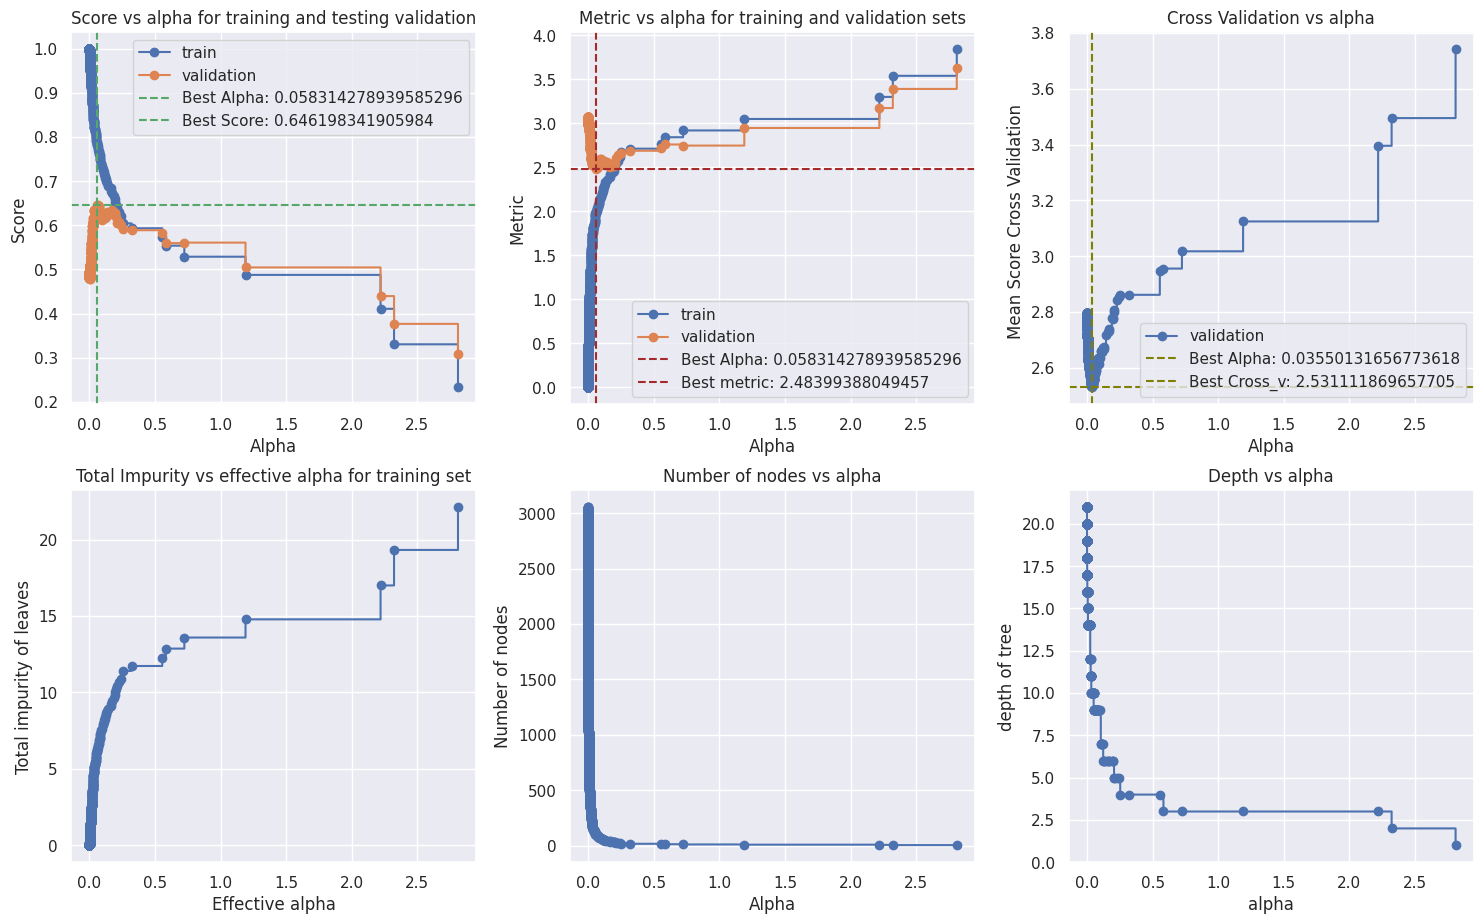

In [28]:
cost_complexity_pruning_plot(
    i_score_val,
    i_metric,
    i_cross,
    ccp_alphas[1:-1],
    impurities[1:-1],
    node_counts[1:-1],
    depth[1:-1],
    train_scores[1:-1],
    val_scores[1:-1],
    cro_cv[1:-1],
    score_trainer[1:-1],
    score_val[1:-1])


The top plots identify the optimal generalization point based on R², MAE, and cross-validation.

The bottom plots illustrate the structural cost of pruning, showing how the number of nodes and tree depth decrease as impurity increases.


**Score vs Alpha (Training vs. Validation)**
- When ccp_alpha ≈ 0, the tree achieves an R² close to 1.0 on the training set, but its validation performance is considerably lower.
- As ccp_alpha increases, pruning reduces the complexity of the tree, causing the training and validation curves to converge.
- As alpha increases, a slight degree of overfitting can still be observed. However, in this case, the increase in alpha is also associated with a decrease in the overall metric performance.
- The best validation performance is achieved at ccp_alpha = 0.058314, indicated by the vertical line, where R² reaches approximately 0.646.

**MAE vs. Alpha (Training vs. Validation)**
- Training MAE increases progressively as the tree is pruned, which is expected because the model loses flexibility.
- Validation MAE initially decreases and then begins to increase again.
The minimum validation error is reached again at ccp_alpha = 0.058314, with an MAE of approximately 2.48.

**Cross-Validation vs. Alpha**
- It is particularly relevant that R² and MAE select exactly the same ccp_alpha, as two independent metrics lead to the same decision.
- The lowest cross-validation error occurs at ccp_alpha = 0.035501.
- This value is slightly lower than the one selected by external validation (0.058314).

**Total Impurity vs. Effective Alpha**
- As ccp_alpha increases, total impurity also increases.
This occurs because pruning removes splits that previously reduced local impurity.
- The increase is gradual at first and becomes more pronounced at higher ccp_alpha values.
- Excessive pruning simplifies the tree, but it also increases the model's structural error.

**Number of Nodes vs. Alpha**
- This plot shows how the size of the tree changes as pruning increases.
Even small values of ccp_alpha lead to a substantial reduction in the number of nodes.
- The greatest gain in simplicity occurs during the early stages of pruning.

**Tree Depth vs. Alpha**
- The initial tree has a depth of approximately 21 levels.
- Tree depth decreases rapidly as ccp_alpha increases.


# **Metrics**
---

In [29]:
model_regresion = DecisionTreeRegressor(random_state=random_seed)

model_regresion.fit(X_train, y_train)
y_predict = model_regresion.predict(X_test)

print(
    f'MSE: {mean_squared_error(y_test, y_predict)}',
    f'RMSE: {root_mean_squared_error(y_test, y_predict)}',
    f'MAE: {mean_absolute_error(y_test, y_predict)}'
)

MSE: 12.799169870921562 RMSE: 3.57759274805302 MAE: 2.8069726954917424


The first model corresponds to a decision tree without any hyperparameter tuning, representing the algorithm’s initial performance. The results show that this model has a higher prediction error. This model therefore serves as a baseline for determining whether the hyperparameter tuning process leads to an improvement in model performance.

In [30]:
model_regresion = DecisionTreeRegressor(random_state=random_seed, ccp_alpha=dta.iloc[0,1])

model_regresion.fit(X_train, y_train)
y_predict = model_regresion.predict(X_test)
print(
    f'MSE: {mean_squared_error(y_test, y_predict)}',
    f'RMSE: {root_mean_squared_error(y_test, y_predict)}',
    f'MAE: {mean_absolute_error(y_test, y_predict)}'
)

MSE: 10.276071165396607 RMSE: 3.205631164902882 MAE: 2.6389742307818915


Al realizar el ajuste del árbol utilizando R², se observa una reducción de los valores de error con respecto al modelo inicial. Esto representa que la configuración seleccionada permite que el árbol genere predicciones más cercanas a los valores reales. En otras palabras, el ajuste de los parámetros permitió obtener un modelo con un mejor comportamiento predictivo que el árbol utilizado inicialmente.

In [31]:
model_regresion = DecisionTreeRegressor(random_state=random_seed, ccp_alpha=dta.iloc[1,1])

model_regresion.fit(X_train, y_train)
y_predict = model_regresion.predict(X_test)
print(
    f'MSE: {mean_squared_error(y_test, y_predict)}',
    f'RMSE: {root_mean_squared_error(y_test, y_predict)}',
    f'MAE: {mean_absolute_error(y_test, y_predict)}'
)

MSE: 10.276071165396607 RMSE: 3.205631164902882 MAE: 2.6389742307818915


For the decision tree tuned using MAE, exactly the same results were obtained as with the R²-based tuning approach. This indicates that, for the dataset analyzed, both selection strategies ultimately identified a configuration that produced the same predictive performance on the evaluation set. Therefore, no difference in final performance was observed between these two approaches.

In [32]:
model_regresion = DecisionTreeRegressor(random_state=random_seed, ccp_alpha=dta.iloc[2,1])

model_regresion.fit(X_train, y_train)
y_predict = model_regresion.predict(X_test)
print(
    f'MSE: {mean_squared_error(y_test, y_predict)}',
    f'RMSE: {root_mean_squared_error(y_test, y_predict)}',
    f'MAE: {mean_absolute_error(y_test, y_predict)}'
)

MSE: 9.37832500465239 RMSE: 3.0624051013300626 MAE: 2.499784994183172


The decision tree tuned using cross-validation achieves the lowest error values among all the models evaluated. This indicates that, among the configurations considered, this model produces predictions that are closer to the observed values and therefore exhibits the best predictive performance of the four models.

# **Calsification**
---

- A synthetic dataset was generated for a binary classification problem using the make_classification() function from Scikit-Learn. The dataset was designed with 2,000 observations and 8 predictor variables, 5 of which correspond to informative features containing the signal used to distinguish between the two classes.


- To simulate a scenario closer to a real-world problem, an imbalanced class distribution was introduced using weights=[0.75, 0.25], where 75% of the observations belong to the majority class and 25% to the minority class. In addition, a single cluster per class was specified to produce more well-defined decision boundaries, while random_state ensures full reproducibility of the dataset.

In [34]:
X, y = make_classification(
    n_samples=2000,
    n_features=8,
    n_informative=5,
    n_redundant=0,
    random_state=random_seed,
    n_clusters_per_class=1,
    weights=[0.75, 0.25])

**Data Split**

The dataset was partitioned into three independent subsets to preserve a rigorous model evaluation workflow. First, 80% of the data was allocated to the training set, while the remaining 20% was reserved as the test set for the final evaluation.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=random_seed, stratify=y)

Next, the training set was further divided into 85% for model training and 15% for validation. The validation set was used during hyperparameter selection and model optimization, whereas the test set remained completely isolated to provide an unbiased assessment of the final model's generalization performance.

In [39]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.85, random_state=random_seed, stratify=y_train)

The stratify parameter was applied in both partitions to preserve the original class distribution across the training, validation, and test sets, ensuring that the class imbalance remained consistent throughout the entire workflow.

**Model**

A Decision Tree Classifier was initialized with a fixed random_state to ensure reproducible model training. At this stage, no pruning or hyperparameters were applied, allowing the classifier to be trained initially with its default configuration before evaluating and optimizing its complexity.

In [40]:
model_clasification = DecisionTreeClassifier(random_state=random_seed)

Using the previously instantiated, untuned decision tree, the cost-complexity pruning path was calculated with:

cost = model_regresion.cost_complexity_pruning_path(X_train, y_train)

The resulting values were then extracted as follows:

ccp_alphas, impurities = cost.ccp_alphas, cost.impurities

These values were used to analyze the relationship between the effective alpha (ccp_alpha) and the total impurity of the tree, providing the candidate pruning parameters for the subsequent model evaluation.

In [41]:
cost = model_regresion.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = cost.ccp_alphas, cost.impurities

For each ccp_alpha value obtained from the cost-complexity pruning path, a decision tree classifier was initialized and evaluated. The model was assessed using 10-fold cross-validation on the training set, with Recall as the evaluation metric. After fitting each tree to the training data, the accuracy scores on the training and validation sets were recorded, along with the Recall scores for both datasets. In addition, the number of nodes and maximum depth of each pruned tree were stored to analyze how pruning affects the structural complexity of the model. Finally, each trained decision tree was saved for subsequent analysis and comparison. This process allows the effect of different pruning levels on both predictive performance and model complexity to be evaluated.

In [42]:
# Initialize lists to store the number of nodes for each pruned tree
node_counts = []
# Initialize a list to store the maximum depth of each pruned tree
depth = []
# Initialize a list to store the Recall on the training set for each ccp_alpha
train_scores = []
# Initialize a list to store the Recall on the validation set for each ccp_alpha
val_scores = []
# Initialize a list to store each trained decision tree
models = []
# Initialize a list to store the mean cross-validation Recall for each ccp_alpha
cro_cv = []
# Initialize a list to store the accuracy score on the training set for each ccp_alpha
score_trainer = []
# Initialize a list to store the accuracy score on the test set for each ccp_alpha
score_val = []
# Initialize a list to store the Raccuracy score on the validation set for each ccp_alpha
for ccp_alpha in ccp_alphas:
  # Initialize a decision tree with the current ccp_alpha value
  model = DecisionTreeClassifier(random_state=random_seed, ccp_alpha=ccp_alpha)
  # Evaluate the model using 10-fold cross-validation on the training set
  cro_cv.append(cross_val_score(model, X_train, y_train, cv=10, scoring='recall').mean())
  # Fit the tree using the training data
  model.fit(X_train, y_train)
  # Store the accuracy score obtained on the training set
  score_trainer.append(model.score(X_train, y_train))
  # Store the accuracy score obtained on the test set
  score_val.append(model.score(X_val, y_val))
  # Store the number of nodes in the pruned tree
  node_counts.append(model.tree_.node_count)
  # Store the maximum depth of the pruned tree
  depth.append(model.tree_.max_depth)
  # Calculate and store the Recall on the training set
  train_scores.append(recall_score(y_train, model.predict(X_train)))
  # Calculate and store the Recall on the test set
  val_scores.append(recall_score(y_val, model.predict(X_val)))
  # Store the trained model for each ccp_alpha
  models.append(model)

Three different methods were used to select the best ccp_alpha value. The first method was based on the validation score, which corresponds to the model's accuracy. The second method used Recall as the evaluation metric, while the third method was based on the cross-validation score. For each method, the ccp_alpha value that achieved the best performance according to the corresponding criterion was selected. The remaining parameters, including the number of nodes, total impurity, and tree depth, were retained as additional information to characterize the resulting pruned trees and analyze their structural complexity.

In [50]:
dta, i_score_val, i_metric, i_cross = select_best_ccp_alphas(
    ccp_alphas[1:-1],
    score_val[1:-1],
    val_scores[1:-1],
    cro_cv[1:-1],
    node_counts,
    impurities,
    depth,
    typ = 'C'
)
dta

,,ccp_alphas,metric value,impurities,nodes,depth
0,Score,0.003019,0.979167,0.028752,33,10
1,Metric,0.000363,0.933333,0.000000,95,12
2,cv-n,0.000882,0.906303,0.012828,95,12


The three pruning strategies selected different ccp_alpha values, resulting in different levels of model complexity. The Score-based method selected ccp_alpha = 0.003019, achieving the highest metric value of 0.979167. This configuration produced the simplest tree among the three approaches, with 29 nodes and a maximum depth of 8, while maintaining a relatively low impurity of 0.031771.

The Metric-based method, which uses Recall as its selection criterion, selected ccp_alpha = 0.000000, resulting in a metric value of 0.933333. Since no pruning was applied, this configuration produced the most complex tree, with 95 nodes and a maximum depth of 12, while total impurity remained at 0.000000.

Finally, the cross-validation method selected ccp_alpha = 0.000882, with a metric value of 0.906303. This resulted in an intermediate model complexity, with 63 nodes and a maximum depth of 10, and a total impurity of 0.016357. Overall, the three approaches illustrate the trade-off between predictive performance and model complexity: the Score-based method achieved the highest metric value while also producing the simplest tree, whereas the Metric-based approach retained the most complex structure due to selecting no pruning.

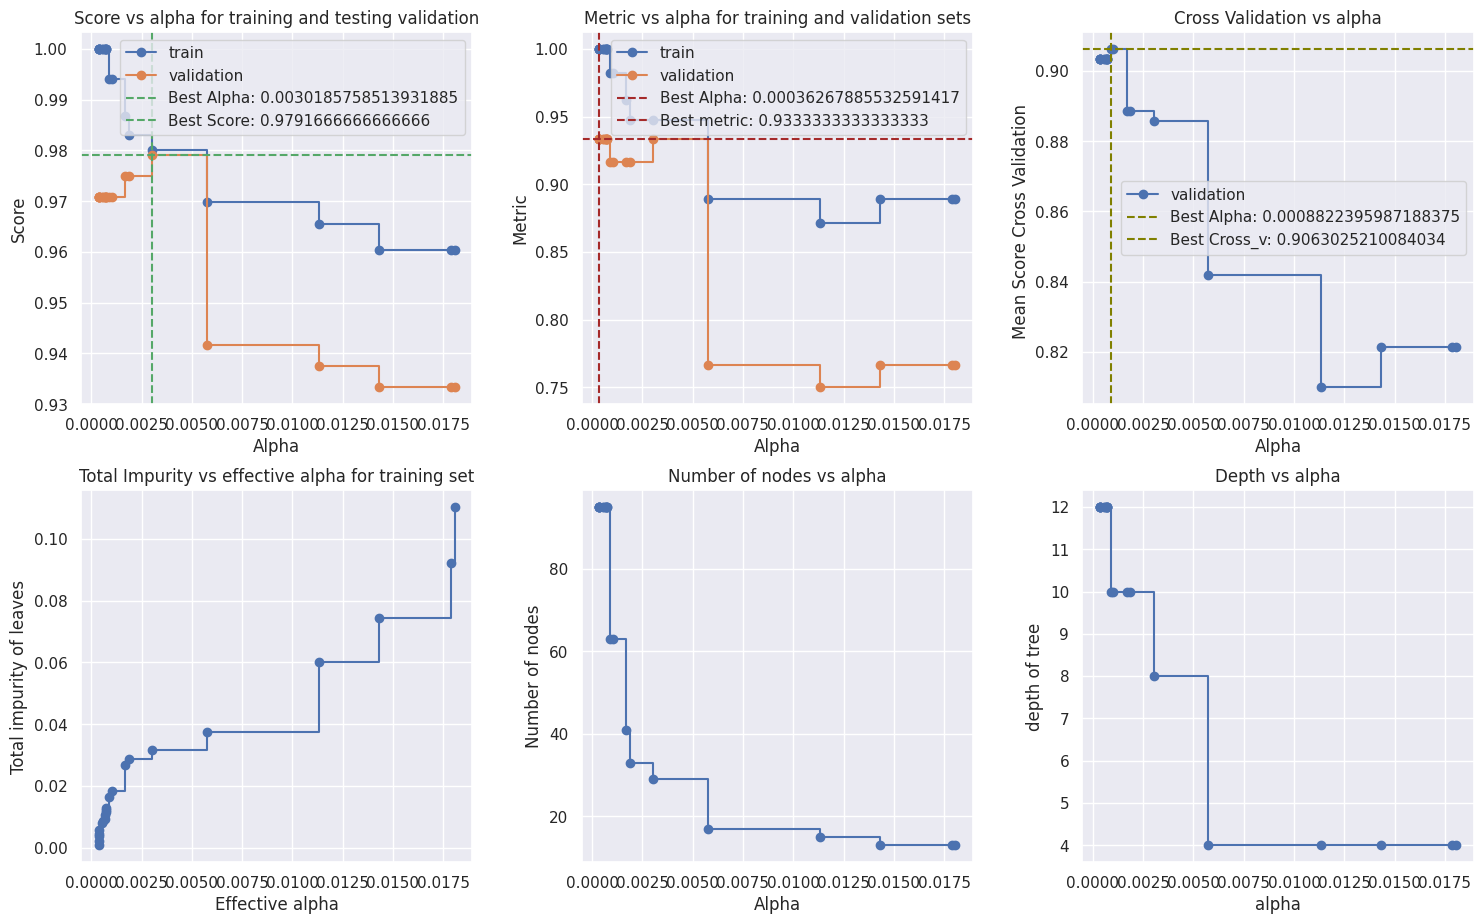

In [51]:
cost_complexity_pruning_plot(
    i_score_val,
    i_metric,
    i_cross,
    ccp_alphas[1:-1],
    impurities[1:-1],
    node_counts[1:-1],
    depth[1:-1],
    train_scores[1:-1],
    val_scores[1:-1],
    cro_cv[1:-1],
    score_trainer[1:-1],
    score_val[1:-1])

The top plots identify the optimal generalization point based on Accuracy, Recall and cross-validation.

The bottom plots illustrate the structural cost of pruning, showing how the number of nodes and tree depth decrease as impurity increases.


**Score vs. alpha**

The first plot shows the behavior of the decision tree’s score on the training and validation sets as the value of ccp_alpha increases. For very small values of ccp_alpha, the tree maintains a highly complex structure and achieves nearly perfect performance on the training set. However, as ccp_alpha increases, progressively stronger pruning is applied, causing training performance to decline. In contrast, the validation set initially shows a gradual improvement, reaching its best performance at ccp_alpha = 0.0030185758513931885, with a score of approximately 0.97917. Beyond this point, validation performance decreases considerably, indicating that excessive pruning begins to remove useful predictive structure.

This behavior makes it possible to identify a trade-off between model complexity and predictive performance. At extremely low values of ccp_alpha, the tree retains many branches and achieves very high performance on the training set, but its validation performance is lower. Increasing ccp_alpha to approximately 0.00302 results in the best generalization observed on this validation set. Beyond this value, the reduction in model complexity begins to negatively affect predictive performance. Therefore, under this specific selection criterion, ccp_alpha = 0.0030185758513931885 represents the optimal candidate, using only the training and validation sets, while the test set should remain held out for the final evaluation.




**Metric vs Alpha**

The second plot analyzes the effect of ccp_alpha using a specific classification metric rather than the score used in the first plot. In this case, the best validation-set metric is obtained at ccp_alpha = 0.00036267885532591417, reaching a value of approximately 0.93333. The observed behavior shows that the validation metric remains relatively stable for small values of ccp_alpha, but begins to deteriorate as the level of pruning increases. This indicates that, from the perspective of this particular metric, even moderate pruning may begin to remove splits that provide relevant information for classification.

The difference between the alpha selected in this plot and the one selected using the score from the first plot is important. It does not necessarily mean that one of the results is incorrect; rather, each procedure is optimizing a different criterion. The first analysis aims to maximize the score used by the model, whereas the second aims to maximize a specific classification metric. Depending on the objective of the problem—for example, prioritizing accuracy, F1 score, recall, or precision—the optimal ccp_alpha may change. This demonstrates that hyperparameter selection should be aligned with the metric that best represents the predictive objective of the problem.


**Cross Validation vs Alpha**
The third plot incorporates Cross-Validation to evaluate the different values of ccp_alpha. In this case, each candidate value is evaluated across multiple data splits from the training set, after which an average performance is obtained. The results indicate that the best value corresponds to ccp_alpha = 0.0008822395987188375, with an average cross-validation score of approximately 0.90630. Unlike the two previous plots, this result does not depend exclusively on a single training-validation split, but rather on the model’s average performance across the different partitions used during cross-validation.

This procedure provides a more robust estimate of the model’s expected behavior across different subsets of the data. The fact that Cross-Validation selects a different ccp_alpha from the other two methods is expected, since the evaluation is based on a different statistical criterion. In particular, the value selected through Cross-Validation is considerably lower than the value selected under the first criterion, suggesting that when the tree is evaluated across multiple data partitions, retaining a larger portion of the tree’s original structure results in better average performance.


**Total Impurity vs Effective Alpha**

The fourth plot shows the relationship between the effective alpha and the total impurity of the leaves in the training tree. An increasing trend can be observed: as the value of ccp_alpha increases, the total impurity also increases. This occurs because pruning removes tree splits that previously allowed subsets of observations to be separated into more homogeneous groups. As a result, the remaining leaves contain progressively more heterogeneous groups and therefore exhibit higher impurity.

This behavior is consistent with the principle of Cost-Complexity Pruning. A more complex tree can perform a larger number of splits and substantially reduce the impurity of its leaves, whereas a more heavily pruned tree sacrifices part of this impurity reduction in exchange for a simpler structure. Therefore, this plot should not be interpreted as an indication that a particular alpha is predictively “better,” but rather as evidence of the structural cost associated with simplifying the tree. The increase in impurity represents precisely one of the expected effects of reducing model complexity.


**Number of Nodes vs Alpha**
The fifth plot directly shows how ccp_alpha controls the size of the tree through the number of nodes. For very small values of alpha, the tree contains approximately 95 nodes, representing a highly complex structure. As ccp_alpha increases, the number of nodes decreases in a stepwise manner, passing through approximately 63, 41, 33, 29, 17, 15, and finally 13 nodes. These changes show that the pruning process does not necessarily remove one node at a time; instead, it can eliminate entire branches when they no longer justify their contribution to impurity reduction relative to the complexity penalty.

**Depth vs Alpha**
La sexta gráfica muestra el efecto de ccp_alpha sobre la profundidad máxima del árbol. El árbol comienza con una profundidad aproximada de 12 niveles, lo que indica una estructura considerablemente compleja. Con el incremento de ccp_alpha, la profundidad se reduce progresivamente: primero pasa aproximadamente de 12 a 10, posteriormente a 8 y finalmente a 4 niveles. Una vez que el árbol alcanza una profundidad de cuatro, incrementos adicionales de alpha no producen una reducción adicional de esta característica, aunque todavía pueden existir cambios en otras propiedades estructurales del árbol.

In [52]:
model_clasification = DecisionTreeClassifier(random_state=random_seed)

model_clasification.fit(X_train, y_train)
y_predict = model_clasification.predict(X_test)

print(
    f'Precision: {precision_score(y_test, y_predict)}',
    f'Recall: {recall_score(y_test, y_predict)}'
)

Precision: 0.8703703703703703 Recall: 0.9306930693069307


When using the decision tree without performing any hyperparameter tuning, the model achieves a precision of 87.04% and a recall of 93.07%. This indicates that the model correctly identifies a large proportion of the positive cases, although its predictions have lower precision. Since this is a fully grown tree, it serves as a baseline model for comparing the results obtained after applying the different tuning approaches.

In [53]:
model_clasification = DecisionTreeClassifier(random_state=random_seed, ccp_alpha=dta.iloc[0,1])

model_clasification.fit(X_train, y_train)
y_predict = model_clasification.predict(X_test)

print(
    f'Precision: {precision_score(y_test, y_predict)}',
    f'Recall: {recall_score(y_test, y_predict)}'
)

Precision: 0.9387755102040817 Recall: 0.9108910891089109


When tuning the tree using the best parameter obtained based on Accuracy, precision increases to 93.88%, while recall decreases slightly to 91.09%. This indicates that the selected configuration enables the model to make more accurate positive predictions, reducing the number of false positives. In other words, tuning based on Accuracy resulted in a model with higher precision in its predictions, while slightly sacrificing its ability to identify all positive cases.

In [54]:
model_clasification = DecisionTreeClassifier(random_state=random_seed, ccp_alpha=dta.iloc[1,1])

model_clasification.fit(X_train, y_train)
y_predict = model_clasification.predict(X_test)

print(
    f'Precision: {precision_score(y_test, y_predict)}',
    f'Recall: {recall_score(y_test, y_predict)}'
)

Precision: 0.8703703703703703 Recall: 0.9306930693069307


When tuning the tree using the parameter selected based on Recall, the model achieves a precision of 87.04% and a recall of 93.07%. These values are identical to those obtained by the tree without hyperparameter tuning. This indicates that the configuration selected based on Recall did not produce a significant change in the model’s behavior compared with the initial tree. Therefore, although the hyperparameter was selected with the goal of prioritizing the identification of positive cases, the final performance remained unchanged.

In [55]:
model_clasification = DecisionTreeClassifier(random_state=random_seed, ccp_alpha=dta.iloc[2,1])

model_clasification.fit(X_train, y_train)
y_predict = model_clasification.predict(X_test)

print(
    f'Precision: {precision_score(y_test, y_predict)}',
    f'Recall: {recall_score(y_test, y_predict)}'
)

Precision: 0.8921568627450981 Recall: 0.900990099009901


When tuning the tree using the parameter selected through Cross-Validation, the model achieves a precision of 89.22% and a recall of 90.10%. This represents a more balanced performance between the two metrics, as the model maintains a good ability to make correct positive predictions while also identifying actual positive cases. In other words, using Cross-Validation allowed for the selection of a configuration with a balanced performance between precision and recall.

# **Utils**
---

In [ ]:
def select_best_ccp_alphas(
    ccp_alphas,
    score_val,
    val_scores,
    cro_cv,
    node_counts,
    impurities,
    depth,
    typ = 'R'
):

  i_score_val = score_val.index(max(score_val))
  i_metric= 0
  i_cross = 0
  if typ=='R':
    i_metric = val_scores.index(min(val_scores))
    i_cross = cro_cv.index(min(cro_cv))
  elif typ=='C':
    i_metric = val_scores.index(max(val_scores))
    i_cross = cro_cv.index(max(cro_cv))

  dta = [
        (
            'Score',
            ccp_alphas[i_score_val],
            score_val[i_score_val],
            impurities[i_score_val],
            node_counts[i_score_val],
            depth[i_score_val],

        ),
        (
            'Metric',
            ccp_alphas[i_metric],
            val_scores[i_metric],
            impurities[i_metric],
            node_counts[i_metric],
            depth[i_metric],

        ),
        (
            'cv-n',
            ccp_alphas[i_cross],
            cro_cv[i_cross],
            impurities[i_cross],
            node_counts[i_cross],
            depth[i_cross],

        )
    ]
  dta = pd.DataFrame(dta, columns=
     ['', 'ccp_alphas', 'metric value', 'impurities', 'nodes', 'depth'])

  return dta, i_score_val, i_metric, i_cross




def cost_complexity_pruning_plot(
  i_score_val,
  i_metric,
  i_cross,
  ccp_alphas,
  impurities,
  node_counts,
  depth,
  train_scores,
  val_scores,
  cro_cv,
  score_trainer,
  score_val
):
  try:

    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,10))
    ax[0,0].plot(ccp_alphas, score_trainer, marker="o", label="train", drawstyle="steps-post")
    ax[0,0].plot(ccp_alphas, score_val, marker="o", label="validation", drawstyle="steps-post")
    ax[0,0].set_xlabel("Alpha")
    ax[0,0].set_ylabel("Score")
    ax[0,0].set_title("Score vs alpha for training and testing validation")

    ax[0,0].axvline(ccp_alphas[i_score_val], linestyle='--', label=f'Best Alpha: {ccp_alphas[i_score_val]}', color='g')
    ax[0,0].axhline(score_val[i_score_val], linestyle='--', label=f'Best Score: {score_val[i_score_val]}', color='g')
    ax[0,0].legend()

    ax[0,1].plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
    ax[0,1].plot(ccp_alphas, val_scores, marker="o", label="validation", drawstyle="steps-post")
    ax[0,1].set_xlabel("Alpha")
    ax[0,1].set_ylabel("Metric")
    ax[0,1].set_title("Metric vs alpha for training and validation sets")
    ax[0,1].axvline(ccp_alphas[i_metric], linestyle='--', label=f'Best Alpha: {ccp_alphas[i_metric]}', color='brown')
    ax[0,1].axhline(val_scores[i_metric], linestyle='--', label=f'Best metric: {val_scores[i_metric]}', color='brown')
    ax[0,1].legend()

    ax[0,2].plot(ccp_alphas, cro_cv, marker="o", label="validation", drawstyle="steps-post")
    ax[0,2].set_xlabel("Alpha")
    ax[0,2].set_ylabel("Mean Score Cross Validation ")
    ax[0,2].set_title("Cross Validation vs alpha")
    ax[0,2].axvline(ccp_alphas[i_cross], linestyle='--', label=f'Best Alpha: {ccp_alphas[i_cross]}', color='olive')
    ax[0,2].axhline(cro_cv[i_cross], linestyle='--', label=f'Best Cross_v: {cro_cv[i_cross]}', color='olive')
    ax[0,2].legend()

    ax[1,0].plot(ccp_alphas, impurities, marker="o", drawstyle='steps-post')
    ax[1,0].set_xlabel("Effective alpha")
    ax[1,0].set_ylabel("Total impurity of leaves")
    ax[1,0].set_title("Total Impurity vs effective alpha for training set")

    ax[1,1].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
    ax[1,1].set_xlabel("Alpha")
    ax[1,1].set_ylabel("Number of nodes")
    ax[1,1].set_title("Number of nodes vs alpha")

    ax[1,2].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
    ax[1,2].set_xlabel("alpha")
    ax[1,2].set_ylabel("depth of tree")
    ax[1,2].set_title("Depth vs alpha")
    fig.tight_layout()
    plt.subplots_adjust(top=0.9)
  except Exception as e:
    print(e)

# **Info**
---

**@By**: Steven Bernal

**@Nickname:** Kaiziferr

**@Git**: https://github.com/Kaiziferr